# Common Task: COCA Dataset Preprocessing
**Tailored for Project 3 — Data Augmentation Using Physics-Informed Plaque Growth Simulation**

This notebook builds a preprocessing and data-loading pipeline for the Stanford
COCA dataset, oriented toward calcium lesion template extraction and
physics-based simulation work. The pipeline extracts individual lesion
morphologies, computes Agatston scores for stratification, and prepares a
data loader that serves both whole-volume and lesion-patch access.

In [16]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy import ndimage
from torch.utils.data import Dataset, DataLoader
import torch

In [17]:
DATA_ROOT = Path("../coca_project/data_resampled")
TOTALSEG = Path("../totalseg_masks")
RESULTS = Path("../results/common_task")
RESULTS.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

In [18]:
def discover_patients(root):
    patients = {}
    for pat_dir in sorted(root.iterdir()):
        if not pat_dir.is_dir():
            continue
        niis = sorted(pat_dir.glob("*.nii.gz"))
        if len(niis) < 2:
            continue
        img_path, mask_path = None, None
        for f in niis:
            name = f.name.lower()
            if any(k in name for k in ["seg", "mask", "label", "calcium"]):
                mask_path = f
            else:
                img_path = f
        if img_path is None or mask_path is None:
            if len(niis) == 2:
                arr0 = sitk.GetArrayFromImage(sitk.ReadImage(str(niis[0])))
                if len(np.unique(arr0)) < 20:
                    mask_path, img_path = niis[0], niis[1]
                else:
                    img_path, mask_path = niis[0], niis[1]
            else:
                continue
        patients[pat_dir.name] = {"image": img_path, "mask": mask_path}
    return patients

patients = discover_patients(DATA_ROOT)
print(f"Found {len(patients)} patients with image+mask pairs")

Found 787 patients with image+mask pairs


## HU Windowing

For calcium template extraction we use two complementary windows:
- **Soft tissue window** (W=400, L=40): contextual anatomy for registration
- **Calcium window** (W=1500, L=500): highlights calcified deposits, the
  primary features we will extract as templates

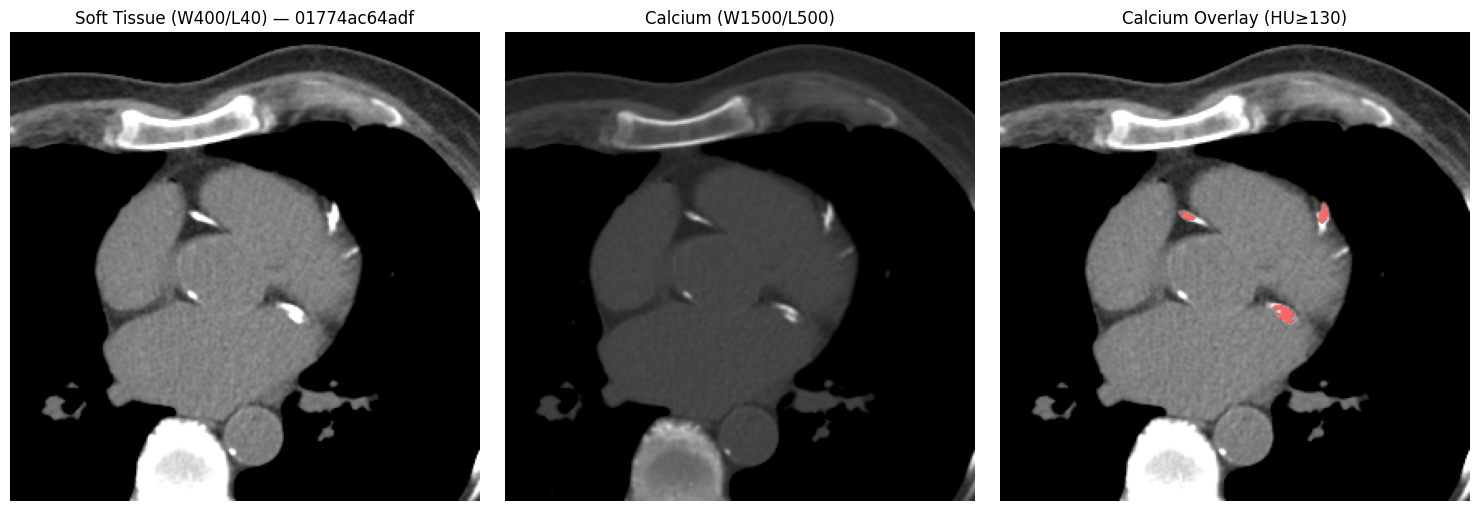

In [19]:
def apply_window(arr, center, width):
    lo = center - width / 2
    hi = center + width / 2
    return np.clip((arr - lo) / (hi - lo), 0, 1).astype(np.float32)

sample_id = None
for pid in patients:
    img_s = sitk.ReadImage(str(patients[pid]["image"]))
    msk_s = sitk.ReadImage(str(patients[pid]["mask"]))
    arr_s = sitk.GetArrayFromImage(img_s).astype(np.float32)
    seg_s = sitk.GetArrayFromImage(msk_s)
    calcium_voxels = (seg_s > 0) & (arr_s >= 130)
    if calcium_voxels.sum() > 50:
        sample_id = pid
        sample_img, sample_mask = img_s, msk_s
        sample_arr, sample_seg = arr_s, seg_s
        break

if sample_id is None:
    sample_id = list(patients.keys())[0]
    sample_img = sitk.ReadImage(str(patients[sample_id]["image"]))
    sample_mask = sitk.ReadImage(str(patients[sample_id]["mask"]))
    sample_arr = sitk.GetArrayFromImage(sample_img).astype(np.float32)
    sample_seg = sitk.GetArrayFromImage(sample_mask)

calcium_mask = (sample_seg > 0) & (sample_arr >= 130)
mid_slices = np.where(calcium_mask)
if len(mid_slices[0]) > 0:
    z_mid = int(np.median(mid_slices[0]))
else:
    z_mid = sample_arr.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(apply_window(sample_arr[z_mid], 40, 400), cmap="gray")
axes[0].set_title(f"Soft Tissue (W400/L40) — {sample_id}")
axes[1].imshow(apply_window(sample_arr[z_mid], 500, 1500), cmap="gray")
axes[1].set_title("Calcium (W1500/L500)")
overlay = apply_window(sample_arr[z_mid], 40, 400)
mask_slice = calcium_mask[z_mid]
axes[2].imshow(overlay, cmap="gray")
axes[2].imshow(np.ma.masked_where(~mask_slice, mask_slice.astype(float)),
               cmap="autumn", alpha=0.6)
axes[2].set_title("Calcium Overlay (HU≥130)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
fig.savefig(RESULTS / "hu_windowing.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-Patient Calcium Statistics & Agatston Scoring

We compute approximate Agatston scores from the resampled volumes for
stratification. Each connected calcium region per slice is scored using the
standard density weighting (130–199 HU → 1, 200–299 → 2, 300–399 → 3, ≥400 → 4).

In [20]:
def compute_agatston(img_sitk, mask_sitk):
    arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
    seg = sitk.GetArrayFromImage(mask_sitk)
    spacing = img_sitk.GetSpacing()
    pixel_area = spacing[0] * spacing[1]

    score = 0.0
    for z in range(arr.shape[0]):
        binary = (seg[z] > 0).astype(np.int32)
        if binary.sum() == 0:
            continue
        labels, n = ndimage.label(binary)
        for lbl in range(1, n + 1):
            region = labels == lbl
            area = region.sum() * pixel_area
            max_hu = arr[z][region].max()
            if max_hu < 130:
                continue
            if max_hu < 200:
                w = 1
            elif max_hu < 300:
                w = 2
            elif max_hu < 400:
                w = 3
            else:
                w = 4
            score += area * w
    return score


def extract_lesion_stats(img_sitk, mask_sitk):
    arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
    seg = sitk.GetArrayFromImage(mask_sitk)
    spacing = np.array(img_sitk.GetSpacing()[::-1])

    binary = ((seg > 0) & (arr >= 130)).astype(np.int32)
    labels_3d, n_lesions = ndimage.label(binary)
    voxel_vol = float(np.prod(spacing))
    total_vol = binary.sum() * voxel_vol

    lesion_vols = []
    for lbl in range(1, n_lesions + 1):
        lesion_vols.append((labels_3d == lbl).sum() * voxel_vol)

    return {
        "n_lesions": n_lesions,
        "total_calcium_vol_mm3": total_vol,
        "lesion_volumes_mm3": lesion_vols,
        "has_calcium": n_lesions > 0,
    }

In [21]:
patient_stats = {}
for i, (pid, paths) in enumerate(patients.items()):
    img = sitk.ReadImage(str(paths["image"]))
    msk = sitk.ReadImage(str(paths["mask"]))
    ag = compute_agatston(img, msk)
    ls = extract_lesion_stats(img, msk)

    if ag == 0:
        cat = "0"
    elif ag < 100:
        cat = "1-99"
    elif ag < 400:
        cat = "100-399"
    else:
        cat = "400+"

    patient_stats[pid] = {
        "agatston": ag,
        "agatston_cat": cat,
        **ls,
    }
    if (i + 1) % 50 == 0:
        print(f"  processed {i + 1}/{len(patients)}")

print(f"Done — {len(patient_stats)} patients")

  processed 50/787
  processed 100/787
  processed 150/787
  processed 200/787
  processed 250/787
  processed 300/787
  processed 350/787
  processed 400/787
  processed 450/787
  processed 500/787
  processed 550/787
  processed 600/787
  processed 650/787
  processed 700/787
  processed 750/787
Done — 787 patients


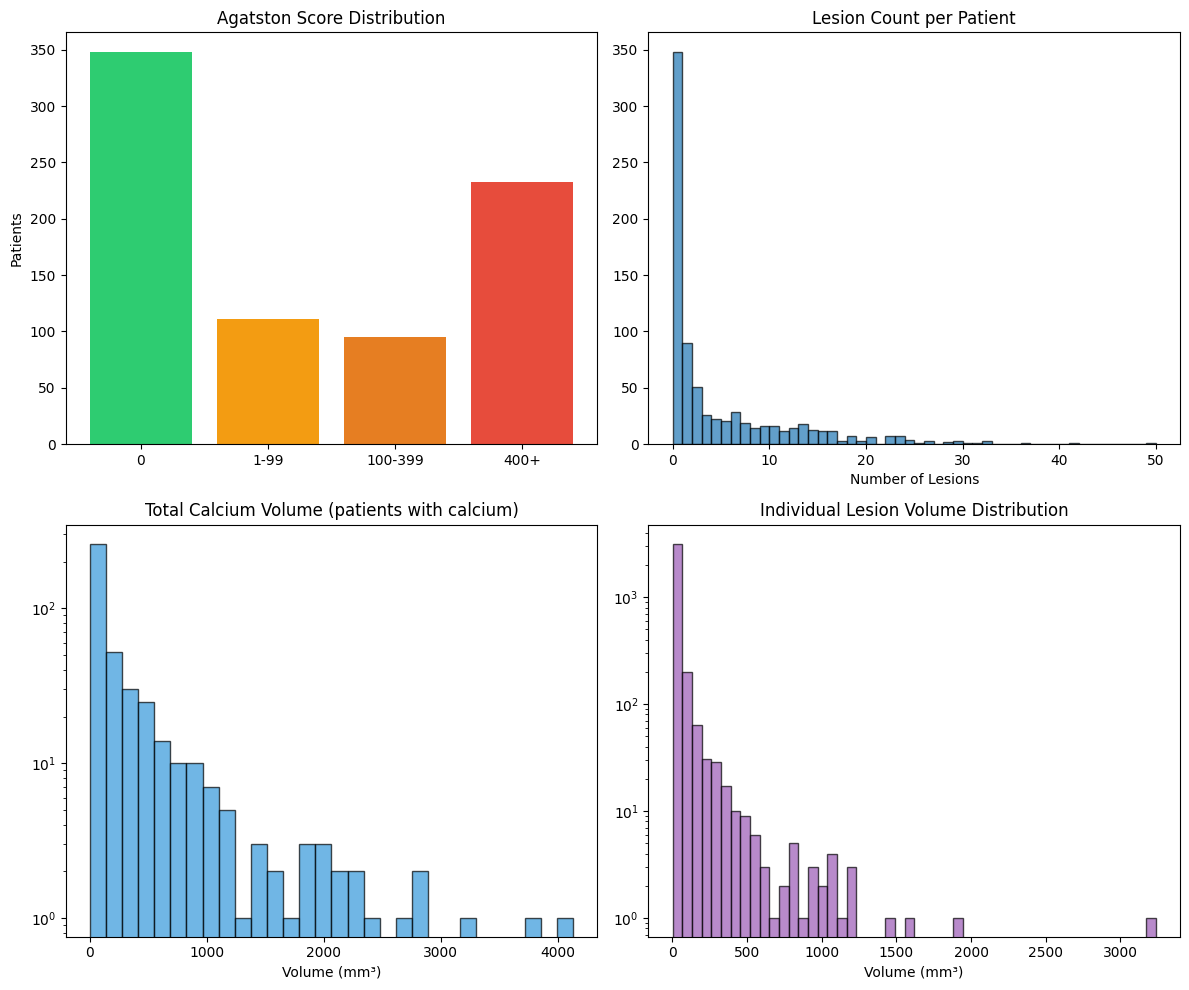


Agatston category distribution:
         0: 348
      1-99: 111
   100-399: 95
      400+: 233
Total lesions across dataset: 3568
Median lesion volume: 8.9 mm³


In [22]:
cats = [s["agatston_cat"] for s in patient_stats.values()]
cat_order = ["0", "1-99", "100-399", "400+"]
cat_counts = {c: cats.count(c) for c in cat_order}

lesion_counts = [s["n_lesions"] for s in patient_stats.values()]
volumes = [s["total_calcium_vol_mm3"] for s in patient_stats.values() if s["has_calcium"]]
all_lesion_vols = []
for s in patient_stats.values():
    all_lesion_vols.extend(s["lesion_volumes_mm3"])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].bar(cat_order, [cat_counts[c] for c in cat_order],
               color=["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"])
axes[0, 0].set_title("Agatston Score Distribution")
axes[0, 0].set_ylabel("Patients")

axes[0, 1].hist(lesion_counts, bins=range(0, max(lesion_counts) + 2),
                edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Lesion Count per Patient")
axes[0, 1].set_xlabel("Number of Lesions")

if volumes:
    axes[1, 0].hist(volumes, bins=30, edgecolor="black", alpha=0.7, color="#3498db")
    axes[1, 0].set_title("Total Calcium Volume (patients with calcium)")
    axes[1, 0].set_xlabel("Volume (mm³)")
    axes[1, 0].set_yscale("log")

if all_lesion_vols:
    axes[1, 1].hist(all_lesion_vols, bins=50, edgecolor="black", alpha=0.7, color="#9b59b6")
    axes[1, 1].set_title("Individual Lesion Volume Distribution")
    axes[1, 1].set_xlabel("Volume (mm³)")
    axes[1, 1].set_yscale("log")

fig.tight_layout()
fig.savefig(RESULTS / "dataset_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAgatston category distribution:")
for c in cat_order:
    print(f"  {c:>8s}: {cat_counts[c]}")
print(f"Total lesions across dataset: {len(all_lesion_vols)}")
if all_lesion_vols:
    print(f"Median lesion volume: {np.median(all_lesion_vols):.1f} mm³")

## Stratified Train / Val / Test Split

We stratify by Agatston category so that each fold sees a representative mix
of calcium burden levels. The ratio is 70 / 15 / 15.

In [23]:
from sklearn.model_selection import train_test_split

pids = list(patient_stats.keys())
labels = [patient_stats[p]["agatston_cat"] for p in pids]

train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    pids, labels, test_size=0.3, stratify=labels, random_state=SEED
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5, stratify=temp_labels, random_state=SEED
)

split = {"train": train_ids, "val": val_ids, "test": test_ids}
with open(RESULTS / "split.json", "w") as f:
    json.dump(split, f, indent=2)

for name, ids in split.items():
    cat_dist = defaultdict(int)
    for pid in ids:
        cat_dist[patient_stats[pid]["agatston_cat"]] += 1
    print(f"{name:>5s} ({len(ids):>3d}): {dict(cat_dist)}")

train (550): {'400+': 163, '100-399': 66, '0': 243, '1-99': 78}
  val (118): {'1-99': 16, '400+': 35, '0': 52, '100-399': 15}
 test (119): {'100-399': 14, '400+': 35, '0': 53, '1-99': 17}


## Data Augmentation Strategy

For physics-based simulation / template extraction, augmentation must preserve
calcium morphology faithfully. We apply only:
- Small rotations (±5°) and translations (±5 voxels)
- Additive Gaussian noise (σ = 15 HU) to simulate scanner variability
- Axis flips (left-right only, anatomically valid)

Heavy elastic deformations or intensity jittering would distort the lesion
shapes that we want to extract as templates — so we deliberately avoid them.

In [24]:
def augment_volume(image, mask, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if rng.random() < 0.5:
        image = np.flip(image, axis=2).copy()
        mask = np.flip(mask, axis=2).copy()

    angle = rng.uniform(-5, 5)
    axes_pair = (1, 2)
    image = ndimage.rotate(image, angle, axes=axes_pair, reshape=False, order=1, mode="nearest")
    mask = ndimage.rotate(mask, angle, axes=axes_pair, reshape=False, order=0, mode="nearest")

    shift = rng.integers(-5, 6, size=3).astype(float)
    shift[0] = 0
    image = ndimage.shift(image, shift, order=1, mode="nearest")
    mask = ndimage.shift(mask, shift, order=0, mode="nearest")

    noise = rng.normal(0, 15, size=image.shape).astype(np.float32)
    image = image + noise

    return image, mask

In [25]:
class COCADataset(Dataset):
    def __init__(self, patient_ids, patient_paths, hu_center=40, hu_width=400,
                 augment=False, seed=42):
        self.ids = patient_ids
        self.paths = patient_paths
        self.hu_center = hu_center
        self.hu_width = hu_width
        self.augment = augment
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        pid = self.ids[idx]
        img = sitk.ReadImage(str(self.paths[pid]["image"]))
        msk = sitk.ReadImage(str(self.paths[pid]["mask"]))
        arr = sitk.GetArrayFromImage(img).astype(np.float32)
        seg = sitk.GetArrayFromImage(msk).astype(np.int64)
        spacing = np.array(img.GetSpacing()[::-1])

        raw_hu = arr.copy()

        if self.augment:
            arr, seg = augment_volume(arr, seg, self.rng)
            raw_hu = arr.copy()

        calcium_binary = ((seg > 0) & (raw_hu >= 130)).astype(np.float32)
        arr = apply_window(arr, self.hu_center, self.hu_width)

        return {
            "image": torch.from_numpy(arr).unsqueeze(0),
            "mask": torch.from_numpy(calcium_binary).unsqueeze(0),
            "mask_labels": torch.from_numpy(seg),
            "raw_hu": torch.from_numpy(raw_hu),
            "spacing": torch.from_numpy(spacing),
            "patient_id": pid,
        }


train_ds = COCADataset(train_ids, patients, augment=True, seed=SEED)
val_ds = COCADataset(val_ids, patients, augment=False, seed=SEED)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Image shape: {batch['image'].shape}")
print(f"Mask shape:  {batch['mask'].shape}")
print(f"Spacing:     {batch['spacing'][0].numpy()}")

Image shape: torch.Size([1, 1, 159, 229, 229])
Mask shape:  torch.Size([1, 1, 159, 229, 229])
Spacing:     [0.69999999 0.69999999 0.69999999]


## Lesion Template Extraction

For Project 3, the critical deliverable is a library of calcium lesion
templates. We extract 3D bounding-box patches around each connected calcium
component, storing the binary morphology and the original HU intensities.
These templates will later be clustered into phenotype families
(spotty / dense / diffuse) for the simulation pipeline.

In [26]:
def extract_lesion_templates(image_arr, mask_arr, spacing, pad=2):
    binary = ((mask_arr > 0) & (image_arr >= 130)).astype(np.int32)
    labels_3d, n = ndimage.label(binary)
    templates = []
    for lbl in range(1, n + 1):
        region_mask = labels_3d == lbl
        if region_mask.sum() < 3:
            continue
        coords = np.argwhere(region_mask)
        mins = coords.min(axis=0) - pad
        maxs = coords.max(axis=0) + pad + 1
        mins = np.clip(mins, 0, np.array(binary.shape) - 1)
        maxs = np.clip(maxs, 1, np.array(binary.shape))

        slices = tuple(slice(lo, hi) for lo, hi in zip(mins, maxs))
        patch_hu = image_arr[slices].copy()
        patch_mask = (labels_3d[slices] == lbl).astype(np.float32)

        vol_mm3 = patch_mask.sum() * float(np.prod(spacing))
        mean_hu = float(image_arr[labels_3d == lbl].mean())
        max_hu = float(image_arr[labels_3d == lbl].max())
        shape_ratio = patch_mask.shape  # z, y, x extents

        templates.append({
            "patch_hu": patch_hu,
            "patch_mask": patch_mask,
            "volume_mm3": vol_mm3,
            "mean_hu": mean_hu,
            "max_hu": max_hu,
            "bbox_shape": shape_ratio,
            "origin_voxel": mins.tolist(),
        })
    return templates

In [27]:
all_templates = []
for pid in train_ids[:50]:
    img = sitk.ReadImage(str(patients[pid]["image"]))
    msk = sitk.ReadImage(str(patients[pid]["mask"]))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    seg = sitk.GetArrayFromImage(msk)
    sp = np.array(img.GetSpacing()[::-1])

    tmps = extract_lesion_templates(arr, seg, sp)
    for t in tmps:
        t["patient_id"] = pid
    all_templates.extend(tmps)

print(f"Extracted {len(all_templates)} lesion templates from first 50 train patients")

Extracted 258 lesion templates from first 50 train patients


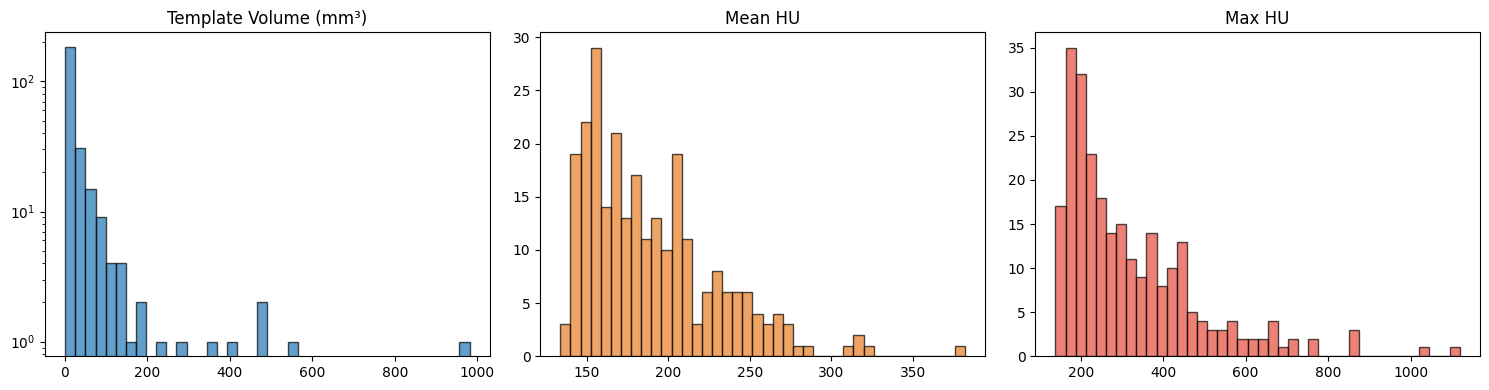

In [28]:
if all_templates:
    vols = [t["volume_mm3"] for t in all_templates]
    hus = [t["mean_hu"] for t in all_templates]
    max_hus = [t["max_hu"] for t in all_templates]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(vols, bins=40, edgecolor="black", alpha=0.7)
    axes[0].set_title("Template Volume (mm³)")
    axes[0].set_yscale("log")
    axes[1].hist(hus, bins=40, edgecolor="black", alpha=0.7, color="#e67e22")
    axes[1].set_title("Mean HU")
    axes[2].hist(max_hus, bins=40, edgecolor="black", alpha=0.7, color="#e74c3c")
    axes[2].set_title("Max HU")
    fig.tight_layout()
    fig.savefig(RESULTS / "lesion_templates_stats.png", dpi=150, bbox_inches="tight")
    plt.show()

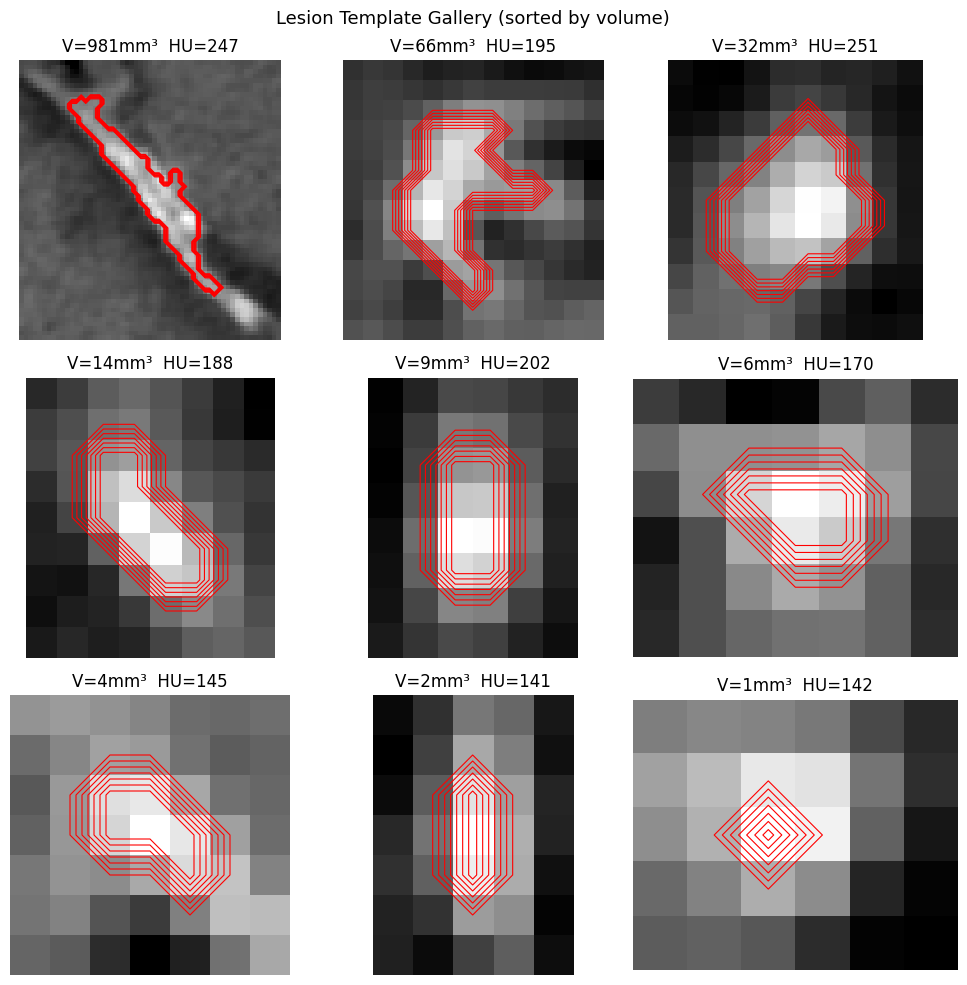

In [29]:
if len(all_templates) >= 9:
    sorted_t = sorted(all_templates, key=lambda x: x["volume_mm3"], reverse=True)
    picks = [sorted_t[i] for i in np.linspace(0, len(sorted_t) - 1, 9).astype(int)]

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for ax, t in zip(axes.flat, picks):
        mid_z = t["patch_mask"].shape[0] // 2
        ax.imshow(apply_window(t["patch_hu"][mid_z], 200, 800), cmap="gray")
        if t["patch_mask"][mid_z].max() > 0:
            ax.contour(t["patch_mask"][mid_z], colors="red", linewidths=0.8)
        ax.set_title(f"V={t['volume_mm3']:.0f}mm³  HU={t['mean_hu']:.0f}")
        ax.axis("off")
    fig.suptitle("Lesion Template Gallery (sorted by volume)", fontsize=13)
    fig.tight_layout()
    fig.savefig(RESULTS / "lesion_template_gallery.png", dpi=150, bbox_inches="tight")
    plt.show()

## Batch Visualization

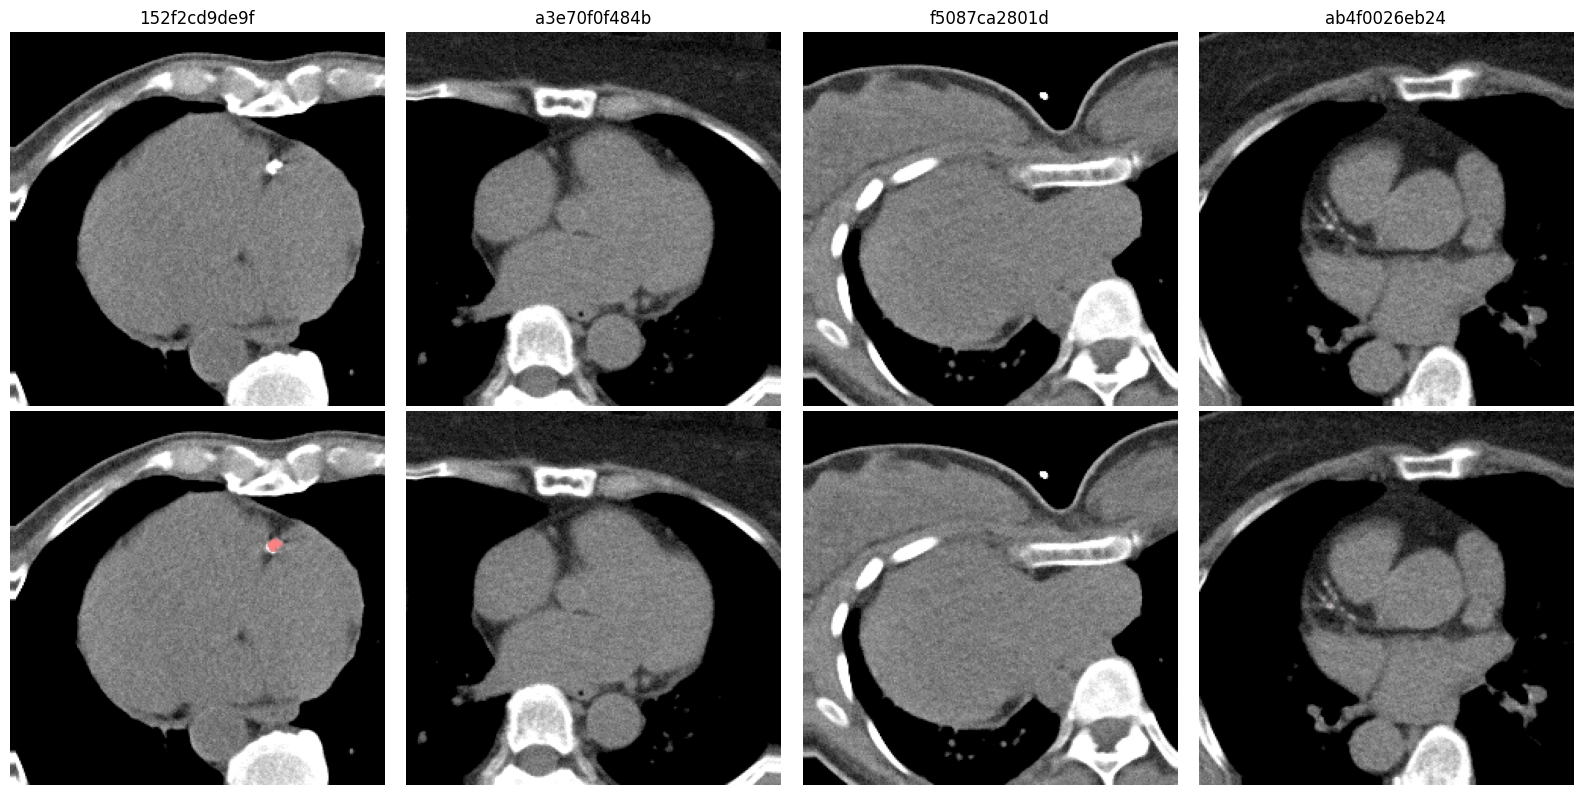

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
shown = 0
for batch in train_loader:
    if shown >= 4:
        break
    vol = batch["image"][0, 0].numpy()
    msk = batch["mask"][0, 0].numpy()
    raw = batch["raw_hu"][0].numpy()

    if vol.max() - vol.min() < 0.01:
        continue

    zs = np.where(msk.sum(axis=(1, 2)) > 0)[0]
    z = int(np.median(zs)) if len(zs) > 0 else vol.shape[0] // 2

    axes[0, shown].imshow(vol[z], cmap="gray")
    axes[0, shown].set_title(batch["patient_id"][0])
    axes[0, shown].axis("off")

    axes[1, shown].imshow(vol[z], cmap="gray")
    if msk[z].sum() > 0:
        axes[1, shown].imshow(np.ma.masked_where(msk[z] < 0.5, msk[z]),
                              cmap="autumn", alpha=0.5)
    axes[1, shown].axis("off")
    shown += 1

axes[0, 0].set_ylabel("CT", fontsize=12)
axes[1, 0].set_ylabel("Calcium Overlay", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS / "batch_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## Justification

The preprocessing pipeline is tailored for physics-based calcium simulation
(Project 3), where the central goal is to build a library of realistic
calcium lesion templates and later place them inside coronary vessel
territories. Two HU windows are used: a soft-tissue window for anatomical
context during atlas registration, and a calcium-specific window for
accurate lesion delineation. The stratified split by Agatston category
ensures every fold contains representative proportions of zero-calcium,
low-, moderate-, and high-burden cases, which is critical because the
simulation pipeline must learn the statistics of all severity levels.

Data augmentation is deliberately conservative — small rotations,
translations, and Gaussian noise — to preserve lesion morphology. Heavy
elastic warps or intensity rescaling would distort the very shapes we need
to faithfully catalog. The lesion template extractor isolates each connected
calcium component as a 3D patch, recording volume, HU statistics, and
bounding-box dimensions. These templates will be clustered downstream
(spotty / dense / diffuse) and used as the morphological building blocks
for the procedural calcium placement engine.